In [1]:
# stamp_viewer env
import numpy as np
import matplotlib.pyplot as plt

In [2]:
results = np.load("results2d_PFB.npy") # (n_ints, snr, repetition)
snrs = np.load("snrs2d_PFB.npy")
n_ints_sim = np.load("n_ints2d_PFB.npy")

In [3]:
print(snrs, len(snrs))
print(n_ints_sim, len(n_ints_sim))

[-1.  -0.5  0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5
  6.   6.5  7.   7.5  8.   8.5] 20
[16] 1


In [4]:
print(results.shape)

(1, 20, 5)


In [5]:
surface = np.mean(results, axis = 2)
error = np.std(results, axis=2)

In [6]:
print(surface)

[[4.02145018e+07 3.34562780e+07 2.62744440e+07 1.86389594e+07
  1.15909490e+07 6.23375020e+06 2.89632340e+06 1.17042880e+06
  4.16196000e+05 1.30962800e+05 3.71846000e+04 9.56940000e+03
  2.26120000e+03 4.79600000e+02 1.14200000e+02 1.84000000e+01
  2.60000000e+00 1.40000000e+00 0.00000000e+00 0.00000000e+00]]


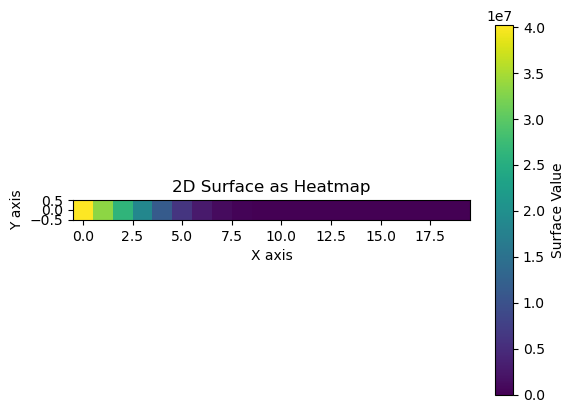

In [7]:
plt.imshow(surface, cmap='viridis', origin='lower')

# Add a color bar to indicate values
plt.colorbar(label='Surface Value')

# Add labels
plt.xlabel('X axis')
plt.ylabel('Y axis')

plt.title('2D Surface as Heatmap')
plt.show()

In [8]:
surface.max()

40214501.8

In [9]:
# from mpl_toolkits.mplot3d import Axes3D

# # Generate X and Y coordinate arrays
# x = snrs  # Number of columns
# y = n_ints_sim # Number of rows
# x, y = np.meshgrid(x, y)   # Create a meshgrid

# # Create the plot
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')

# # Plot the surface
# # z = surface / 
# surf = ax.plot_surface(x, y, z, cmap='viridis')

# # Add a color bar
# # fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

# # ax.set_zscale('log')

# # Labels
# ax.set_xlabel('SNR Threshold')
# ax.set_ylabel('Number of Integrations')
# ax.set_zlabel('False Positives')

# plt.show()

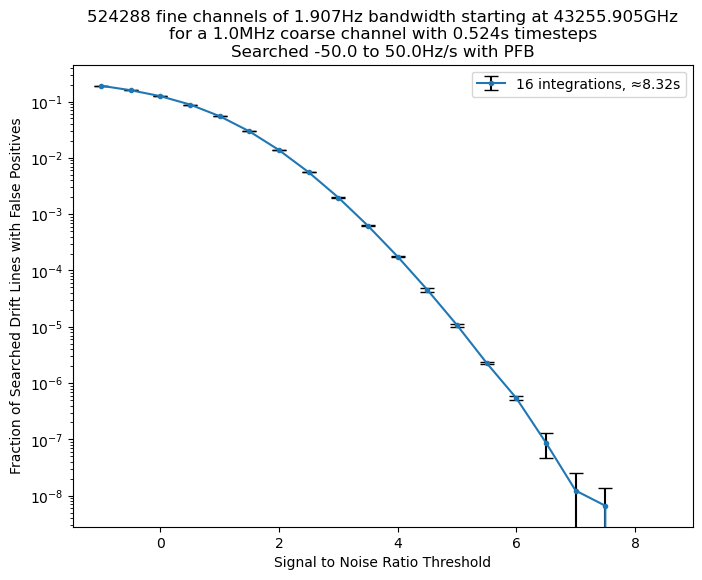

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
possible_signals_per_n_ints = [ 210_752_871, # 4 ints
                                210741766, # 8
                                210719555, # 16 ints
                                210675134, # 32
                                210586292] # 64
# colors = ['b', 'g','r', 'c', 'm']
colors = [u'#1f77b4', u'#ff7f0e', u'#2ca02c', u'#d62728', u'#9467bd']
for i, n_ints in enumerate(n_ints_sim):
        denominator = possible_signals_per_n_ints[i]
        ax.errorbar(snrs, surface[i] / denominator, yerr=error[i] / denominator, marker='.', color=colors[i], ecolor='black', capsize=5, label=f"{n_ints} integrations, ≈{n_ints * 0.52}s")


plt.xlabel("Signal to Noise Ratio Threshold")
plt.ylabel("Fraction of Searched Drift Lines with False Positives")

# Params of run
n_fine = 2**19 # fine channels
drifts = np.arange(-50, 50.25, .25)
f_off = 1.9073486328125e-06 # fine channel spacing
t_samp = 0.524288 # len of integration
freq = 43255.90455616229 # freq of 1st channel
plt.title(f"{n_fine} fine channels of {round(f_off * 1e6, 3)}Hz bandwidth starting at {round(freq, 3)}GHz\n"
           f"for a {n_fine * f_off}MHz coarse channel with {round(t_samp,3)}s timesteps\n"
           f"Searched {min(drifts)} to {max(drifts)}Hz/s with PFB")

plt.yscale('log')
# plt.ylim([1e-15, None])

plt.legend()

plt.show()

In [11]:
results.shape

(1, 20, 5)

In [12]:
from scipy.optimize import curve_fit

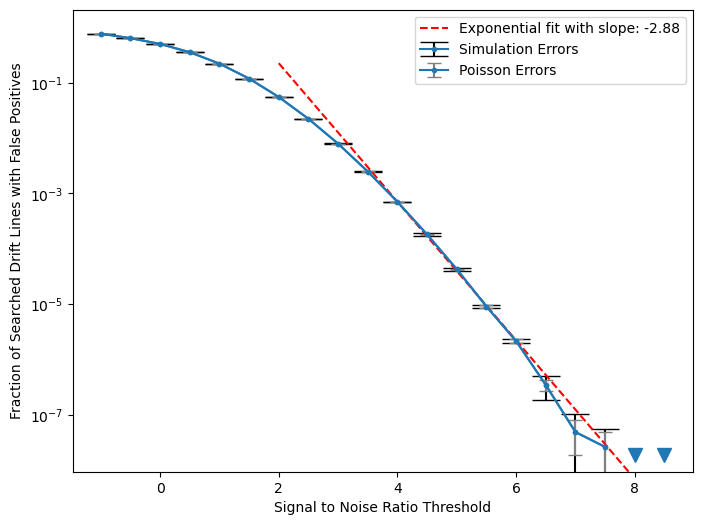

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
# possible_signals_per_n_ints = [ 210_752_871, # 4 ints #### These nums wrong for VLASS, do sim again
#                                 210_741_766, # 8
#                                 210_719_555, # 16 ints 
#                                 210_675_134, # 32
#                                 210_586_292] # 64

# VLASS: 
# 4:
# 8:
# 64: 52_680_106
# 16: 
# 32:

# colors = ['b', 'g','r', 'c', 'm']
colors = [u'#1f77b4', u'#ff7f0e', u'#2ca02c', u'#d62728', u'#9467bd']
for i, n_ints in enumerate(n_ints_sim):
        denominator = 52_680_106
        thresh = 1 / denominator
        zero_fpr = (surface[i] / denominator) <= thresh
        yerr_below_thresh = (error[i] / denominator) <= thresh
        error_for_plotting = np.copy(error[i])
        error_for_plotting = error_for_plotting / denominator
        error_for_plotting[yerr_below_thresh] = thresh
        ax.errorbar(snrs[~zero_fpr], surface[i][~zero_fpr] / denominator, yerr=error_for_plotting[~zero_fpr], marker='.', color=colors[i], ecolor='black', capsize=10, label=f"Simulation Errors")
        
        # Do same plot but with Poisson error
        poisson_error = np.sqrt(surface[i][~zero_fpr]) / denominator
        ax.errorbar(snrs[~zero_fpr], surface[i][~zero_fpr] / denominator, yerr=poisson_error, marker='.', color=colors[i], ecolor='gray', capsize=5, label=f"Poisson Errors")

        # Plot fpr of 0 as a down arrow. FPPR is surface[i]
        number_of_zero_fpr = len(surface[i][zero_fpr])
        ax.plot(snrs[zero_fpr], thresh * np.ones(number_of_zero_fpr), marker='v', color=colors[i], markersize=10, linestyle='')

        # Fit a power law to the data where fpr is not zero
        to_fit = (snrs >= 4) & (snrs <= 6)
        to_fit_x = snrs[to_fit]
        to_fit_y = surface[i][to_fit] / denominator

        # def power_law(x, a, b):
        #     return a * np.power(x, b)

        def exponential(x, a, b):
            return a * np.exp(b * x)

        popt, pcov = curve_fit(exponential, to_fit_x, to_fit_y, absolute_sigma=True, sigma=error_for_plotting[to_fit])

        # print(f"Fitted parameters: a={popt[0]:.4f}, b={popt[1]:.4f}")

        # Plot the fitted curve
        to_plot = (snrs >= 2) & (snrs <= 10)
        ax.plot(snrs[to_plot], exponential(snrs[to_plot], *popt), color='red', linestyle='--', label=f"Exponential fit with slope: {popt[1]:.2f}")

        # # Plot the SNR=8 point
        # snr_8_idx = np.where(snrs == 8)[0][0]
        # plt.axhline(surface[i][snr_8_idx] / denominator, color='red', linestyle=':', label=f"FPR = {surface[i][snr_8_idx] / denominator:.2e} @ SNR=8")

plt.xlabel("Signal to Noise Ratio Threshold")
plt.ylabel("Fraction of Searched Drift Lines with False Positives")

# Params of run
n_ints = n_ints
n_fine = 2**17 # fine channels - 2^17 for VLASS, 2^19 for high freq
drifts = np.arange(-50, 50.25, .25)
f_off = 7.63e-06 # fine channel spacing
t_samp = 8.338608 / n_ints # len of integration
# freq=3000 # freq of 1st channel
# plt.title(f"{n_fine} fine channels of {round(f_off * 1e6, 3)}Hz bandwidth starting at {round(freq, 3)}GHz\n"
#            f"for a {round(n_fine * f_off, 4)}MHz coarse channel with {round(t_samp,3)}s timesteps\n"
#            f"Searched {min(drifts)} to {max(drifts)}Hz/s with NO PFB")

plt.yscale('log')
plt.ylim([0.5 * thresh, None])
# plt.xlim([None, ])

plt.legend()

plt.show()

In [28]:
print(thresh)

1.8982497871207778e-08


In [31]:
52_680_106.0 * 1e-7

5.268010599999999

In [32]:
52_680_106 - 5e7

2680106.0

In [34]:
exponential(10, *popt)

2.226616806240307e-11